# Reação consecutiva A → B → C 
**Objetivo:** este notebook resolve numericamente e plota as concentrações temporais de uma reação consecutiva do tipo A → B → C usando um sistema de EDOs. Você pode ajustar as constantes de velocidade (`k1`, `k2`) e as concentrações iniciais (`A0`, `B0`, `C0`).

---


## Introdução teórica (detalhada)

Consideramos a sequência de reações elementares consecutivas
$$
\mathrm{A}\xrightarrow{k_1}\mathrm{B}\xrightarrow{k_2}\mathrm{C},
$$
onde cada seta representa um **passo elementar**. Para passos unimoleculares elementares, a velocidade do passo é proporcional à concentração do reagente envolvido; por isso $k$ tem unidades de tempo $^{-1}$ (por exemplo, $s^{-1}$) e a cinética é de **primeira ordem** em relação à espécie reagente desse passo.

### Equações de taxa
As equações diferenciais que descrevem a evolução temporal das concentrações $[A]$, $[B]$ e $[C]$ são:
$$
\frac{d[A]}{dt} = -k_1\,[A],
$$
$$
\frac{d[B]}{dt} = +k_1\,[A] - k_2\,[B],
$$
$$
\frac{d[C]}{dt} = +k_2\,[B].
$$

### Interpretação física
- A primeira equação indica que A é consumida com velocidade proporcional a $[A]$; isoladamente, resultaria em um decaimento exponencial $[A]=[A]_0 e^{-k_1 t}$.
- A segunda equação contém um **termo de formação** ($+k_1[A]$) e um **termo de consumo** ($-k_2[B]$). Por isso B pode se acumular de forma transitória e apresentar um **pico** antes de decair.
- A terceira equação mostra que C é formada a partir de B e, no caso fechado com $[A]_0$ inicial e $[B]_0=[C]_0=0$, há conservação de massa:
$$
[A] + [B] + [C] = [A]_0.
$$

### Soluções analíticas (caso $[B]_0=[C]_0=0$)
Quando $k_1\neq k_2$, as soluções analíticas são:
$$
[A] = [A]_0 e^{-k_1 t},
$$
$$
[B] = [A]_0\,\frac{k_1}{k_2-k_1}\left(e^{-k_1 t} - e^{-k_2 t}\right),
$$
$$
[C] = [A]_0\left(1 - \frac{k_2 e^{-k_1 t} - k_1 e^{-k_2 t}}{k_2-k_1}\right).
$$

No caso degenerado $k_1 = k_2 = k$, obtém-se o limite por continuidade:
$$
[A] = [A]_0 e^{-k t},
$$
$$
[B] = [A]_0\,(k t)\,e^{-k t},
$$
$$
[C] = [A]_0\left(1 - e^{-k t}(1 + k t)\right).
$$

### Casos limites e aproximações úteis
- **$k_1 \gg k_2$**: A → B é muito rápido e B → C é lento. B tende a acumular (pico alto e cedo) antes de ser consumido.
- **$k_2 \gg k_1$**: B é convertido em C quase imediatamente ao ser formado; B dificilmente acumula—o sistema se aproxima de uma conversão direta de A para C (regime pseudo-primeiro-ordem).
- **Aproximação de estado estacionário para B**: se B é um intermediário altamente reativo (atinge estado estacionário rapidamente), pode-se aproximar $\dfrac{d[B]}{dt}\approx 0$, obtendo $[B]\approx\dfrac{k_1}{k_2}[A]$. Essa aproximação reduz a complexidade e é válida quando a variação de $[B]$ é muito rápida em comparação às demais escalas temporais do sistema.

---

## Uso
No bloco de código 'Parâmetros e resolução' você pode alterar os valores de `k1`, `k2`, `A0`, `B0`, `C0` e o intervalo de tempo `t_max`/`n_points`. Em seguida execute a célula para obter o gráfico de [A], [B] e [C].


In [99]:
# Imports e definição do sistema de EDOs
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

def edos(concs, t, k1, k2):
    A, B, C = concs
    dAdt = -k1 * A
    dBdt = k1 * A - k2 * B
    dCdt = k2 * B
    return [dAdt, dBdt, dCdt]


In [100]:
# Parâmetros ajustáveis (altere aqui)
k1 = 1.0      # constante de velocidade para A -> B (s^-1)
k2 = 0.5      # constante de velocidade para B -> C (s^-1)
A0 = 1.0      # concentração inicial de A (mol·L^-1)
B0 = 0.0      # concentração inicial de B
C0 = 0.0      # concentração inicial de C
t_max = 10.0  # tempo máximo para integração (s)
n_points = 500  # número de pontos no eixo do tempo

# Vetor de tempo
t = np.linspace(0, t_max, n_points)

# Resolve as EDOs
y0 = [A0, B0, C0]
sol = odeint(edos, y0, t, args=(k1, k2))
A_t, B_t, C_t = sol.T


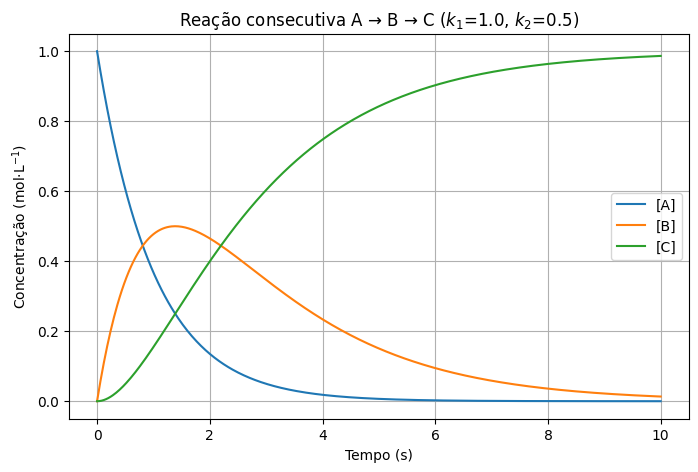

Tempo do pico de B: 1.383 s, valor máximo [B]: 0.50000 mol·L^-1


In [ ]:
# Plot (uma figura por saída)
plt.figure(figsize=(8,5))
plt.plot(t, A_t, label='[A]')
plt.plot(t, B_t, label='[B]')
plt.plot(t, C_t, label='[C]')
plt.xlabel('Tempo (s)')
plt.ylabel('Concentração (mol·L$^{-1}$)')
plt.title(f'Reação consecutiva A → B → C ($k_1$={k1}, $k_2$={k2})')
plt.legend()
plt.grid(True)
plt.show()

# Informação adicional: tempo do pico de B e máximo
idx_peak_B = np.argmax(B_t)
t_peak_B = t[idx_peak_B]
B_peak = B_t[idx_peak_B]
print(f"Tempo do pico de B: {t_peak_B:.3f} s, valor máximo [B]: {B_peak:.5f} mol·L^-1")
#plt.savefig('reacao_consecutiva_A_B_C.png', dpi=300)


___
### Observações finais
- Se `k1 >> k2` a espécie B será formada rapidamente e consumida lentamente (B acumula pouco se k2 for grande).
- Se `k2 >> k1` a conversão de B para C é rápida e B raramente atinge alta concentração.
- Experimente variar os parâmetros para ver regimes diferentes (acumulação de B, regime pseudo-primeiro-ordem, etc.).
